# Klasifikimi i Imazheve HAM10000 me K-Nearest Neighbors (KNN)

Ky notebook perdor datasetin e filtruar HAM10000 per te trajnuar nje model klasifikimi binar (`mel` vs `nv`) duke perdorur algoritmin **K-Nearest Neighbors**.

Inputet e modelit:
1. **Imazhet**: resize ne 32x32, flatten dhe normalizim ne [0, 1].
2. **Metadata**: mosha, gjinia dhe lokalizimi (One-Hot Encoding).

### 1. Importimi i Bibliotekave

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)

### 2. Percaktimi i Folderave

In [2]:
BASE_DIR = os.getcwd()

METADATA_PATH = os.path.join(BASE_DIR, "HAM10000_metadata_filtered.csv")
MEL_DIR = os.path.join(BASE_DIR, "mel")
NV_DIR = os.path.join(BASE_DIR, "nv")

print("Base directory:", BASE_DIR)

Base directory: c:\Users\Dren\Desktop\DermaScan\ham_dataset


### 3. Ngarkimi dhe Pastrimi i Metadata

In [ ]:
df = pd.read_csv(METADATA_PATH)
print(f"Numri total i rreshtave ne metadata: {len(df)}")

df["age"] = df["age"].fillna(df["age"].mean())
df_encoded = pd.get_dummies(df, columns=["sex", "localization"], drop_first=True)
df_encoded["label"] = df_encoded["dx"].map({"nv": 0, "mel": 1})

print("Kolonat pas kodimit:")
print(df_encoded.columns.tolist())
df_encoded.head()

Numri total i rreshtave në metadata: 2226
Kolonat pas kodimit:
['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex_male', 'sex_unknown', 'localization_acral', 'localization_back', 'localization_chest', 'localization_ear', 'localization_face', 'localization_foot', 'localization_genital', 'localization_hand', 'localization_lower extremity', 'localization_neck', 'localization_scalp', 'localization_trunk', 'localization_unknown', 'localization_upper extremity', 'label']


,lesion_id,image_id,dx,dx_type,age,sex_male,sex_unknown,localization_acral,localization_back,localization_chest,...,localization_foot,localization_genital,localization_hand,localization_lower extremity,localization_neck,localization_scalp,localization_trunk,localization_unknown,localization_upper extremity,label
0,HAM_0000871,ISIC_0025964,mel,histo,40.0,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,1
1,HAM_0000871,ISIC_0030623,mel,histo,40.0,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,1
2,HAM_0000040,ISIC_0027190,mel,histo,80.0,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,1
3,HAM_0005678,ISIC_0031023,mel,histo,60.0,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,1
4,HAM_0005678,ISIC_0028086,mel,histo,60.0,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,1


### 4. Ngarkimi i Imazheve dhe Ekstraktimi i Karakteristikave

In [ ]:
images = []
labels = []
meta_features = []

exclude_cols = ["lesion_id", "image_id", "dx", "dx_type", "label"]
meta_cols = [col for col in df_encoded.columns if col not in exclude_cols]

print("Duke ngarkuar fotot dhe duke nxjerre tiparet...")
for _, row in df_encoded.iterrows():
    img_id = row["image_id"]
    label = row["label"]

    img_path = os.path.join(MEL_DIR, f"{img_id}.jpg")
    if not os.path.exists(img_path):
        img_path = os.path.join(NV_DIR, f"{img_id}.jpg")

    if os.path.exists(img_path):
        with Image.open(img_path) as img:
            img_resized = img.resize((32, 32)).convert("RGB")
            img_array = np.array(img_resized).flatten() / 255.0
            images.append(img_array)
            labels.append(label)
            meta_features.append(row[meta_cols].values.astype(float))
    else:
        print(f"Warning: Fotoja {img_id}.jpg nuk u gjet!")

X_img = np.array(images)
X_meta = np.array(meta_features)
y = np.array(labels)

print(f"Dimensioni i matrices se fotove: {X_img.shape}")
print(f"Dimensioni i matrices se metadata: {X_meta.shape}")
print(f"Dimensioni i target label y: {y.shape}")

Duke ngarkuar fotot dhe duke nxjerrë tiparet...
Dimensioni i matricës së fotove: (2226, 3072)
Dimensioni i matricës së metadata: (2226, 17)
Dimensioni i target label y: (2226,)


### 5. Bashkimi i Karakteristikave dhe Ndarja e Datasetit

In [13]:
X = np.hstack((X_img, X_meta))
print(f"Dimensioni total i matrices se inputit X: {X.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Madhesia e Train Set: {X_train.shape[0]}")
print(f"Madhesia e Test Set: {X_test.shape[0]}")

Dimensioni total i matrices se inputit X: (2226, 3089)
Madhesia e Train Set: 1780
Madhesia e Test Set: 446


### 6. Shkallezimi i Karakteristikave (Feature Scaling)

KNN bazohet ne distancen mes pikave, prandaj tiparet duhen standardizuar. StandardScaler pershtatet vetem ne train set per te shmangur data leakage.

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Mesatarja e tipareve pas scaling (train): {X_train_scaled.mean():.4f}")
print(f"Devijimi standard pas scaling (train): {X_train_scaled.std():.4f}")

Mesatarja e tipareve pas scaling (train): 0.0000
Devijimi standard pas scaling (train): 1.0000


### 7. Tuning i Hyperparametrit K

In [7]:
k_values = list(range(1, 32, 2))
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())
    print(f"K={k:2d} -> CV Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

best_k = k_values[int(np.argmax(cv_scores))]
print(f"\nK optimal: {best_k} me CV accuracy {max(cv_scores):.4f}")

K= 1 -> CV Accuracy: 0.6865 (+/- 0.0221)
K= 3 -> CV Accuracy: 0.7034 (+/- 0.0211)
K= 5 -> CV Accuracy: 0.6921 (+/- 0.0208)
K= 7 -> CV Accuracy: 0.6916 (+/- 0.0090)
K= 9 -> CV Accuracy: 0.7006 (+/- 0.0119)
K=11 -> CV Accuracy: 0.7028 (+/- 0.0162)
K=13 -> CV Accuracy: 0.7146 (+/- 0.0131)
K=15 -> CV Accuracy: 0.7157 (+/- 0.0109)
K=17 -> CV Accuracy: 0.7264 (+/- 0.0139)
K=19 -> CV Accuracy: 0.7309 (+/- 0.0112)
K=21 -> CV Accuracy: 0.7281 (+/- 0.0145)
K=23 -> CV Accuracy: 0.7242 (+/- 0.0211)
K=25 -> CV Accuracy: 0.7337 (+/- 0.0121)
K=27 -> CV Accuracy: 0.7404 (+/- 0.0066)
K=29 -> CV Accuracy: 0.7331 (+/- 0.0192)
K=31 -> CV Accuracy: 0.7326 (+/- 0.0145)

K optimal: 27 me CV accuracy 0.7404


### 8. Vizualizimi: Saktësia vs K

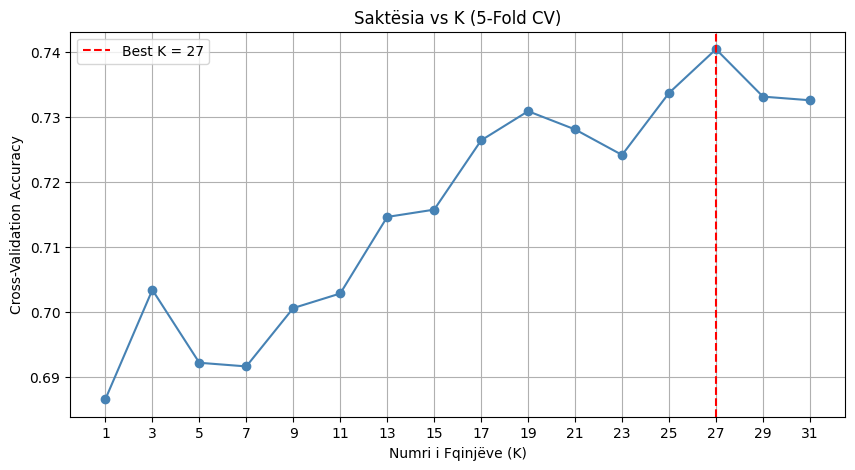

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(k_values, cv_scores, marker="o", color="steelblue")
plt.axvline(best_k, color="red", linestyle="--", label=f"Best K = {best_k}")
plt.xlabel("Numri i Fqinjeve (K)")
plt.ylabel("Cross-Validation Accuracy")
plt.title("Saktesia vs K (5-Fold CV)")
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

### 9. Trajnimi i Modelit Final

In [9]:
print(f"Duke trajnuar KNN me K={best_k}...")

model = KNeighborsClassifier(n_neighbors=best_k, metric="euclidean")
model.fit(X_train_scaled, y_train)

Duke trajnuar KNN me K=27...


,n_neighbors,27
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


### 10. Parashikimi dhe Vleresimi

In [10]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print("\nRaporti i Klasifikimit:")
print(classification_report(y_test, y_pred, target_names=["nv (Nevus)", "mel (Melanoma)"]))

Accuracy:  0.7287
Precision: 0.7237
Recall:    0.7399
F1-score:  0.7317

Raporti i Klasifikimit:
                precision    recall  f1-score   support

    nv (Nevus)       0.73      0.72      0.73       223
mel (Melanoma)       0.72      0.74      0.73       223

      accuracy                           0.73       446
     macro avg       0.73      0.73      0.73       446
  weighted avg       0.73      0.73      0.73       446



### 11. Matrica e Konfuzionit

Confusion Matrix:
[[160  63]
 [ 58 165]]


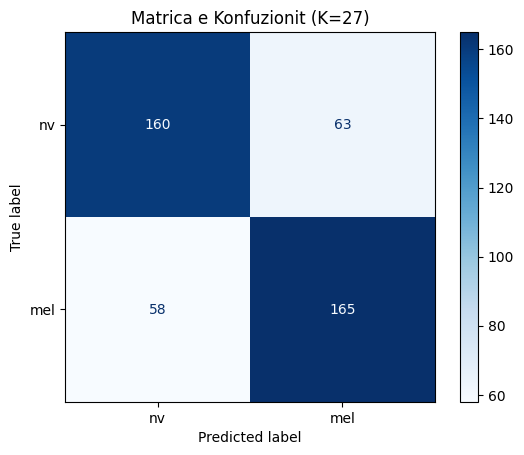

In [11]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["nv", "mel"])
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Matrica e Konfuzionit (K={best_k})")
plt.show()

### 12. Ruajtja e Modelit dhe Scaler-it

In [12]:
model_path = os.path.join(BASE_DIR, "knn_model.pkl")
scaler_path = os.path.join(BASE_DIR, "knn_scaler.pkl")

joblib.dump(model, model_path)
joblib.dump(scaler, scaler_path)

print(f"Modeli u ruajt në: {model_path}")
print(f"Scaler u ruajt në: {scaler_path}")

Modeli u ruajt në: c:\Users\Dren\Desktop\DermaScan\ham_dataset\knn_model.pkl
Scaler u ruajt në: c:\Users\Dren\Desktop\DermaScan\ham_dataset\knn_scaler.pkl
